In [ ]:
# pip install hyperopt jupyter matplotlib pandas requests reservoirpy scikit-learn seaborn

////////////////////////////////////////////////////////////Price Perediction data  prepration


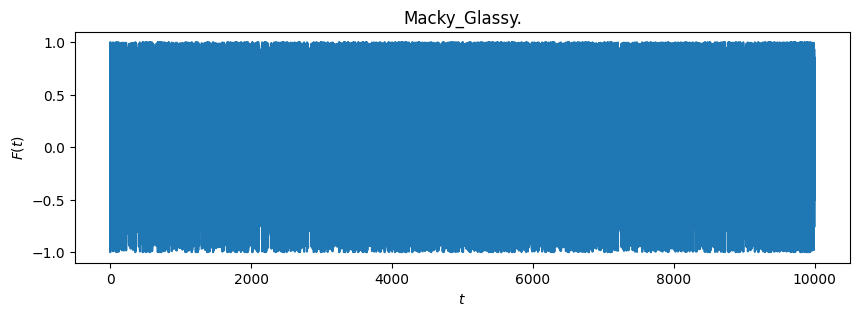

In [1]:
from reservoirpy.datasets import logistic_map
from reservoirpy.nodes import Reservoir, Ridge
import matplotlib.pyplot as plt
X = logistic_map(10000)
X = 2 * (X - X.min()) / (X.max() - X.min()) - 1
# create fxp variable with value 7.25

#reservoir = Reservoir(units=400, lr=0.1, sr=1.25)

#reservoir = Reservoir(10, lr=1, sr=1.25, input_connectivity=0.90,rc_connectivity=0.1,input_scaling=0.001)
# reservoir = Reservoir(40, lr=1, sr=1.25, input_connectivity=0.9,rc_connectivity=0.1,input_scaling=1)

# readout = Ridge(output_dim=1, ridge=1e-8)
# esn_model = reservoir >> readout
# esn_model=esn_model.fit(X[:5000], X[1:5001], warmup=100)


plt.figure(figsize=(10, 3))
plt.title("Macky_Glassy.")
plt.ylabel("$F(t)$")
plt.xlabel("$t$")
plt.plot(X)
plt.show()

In [2]:
dataset = ((X[:5000], X[1:5001]), (X[5000:-1], X[5001:]))

///////////////////////////////////////////////////////////////////////////////////////////

In [3]:
import numpy as np

In [4]:
from reservoirpy.observables import rmse, rsquare

In [5]:
# Objective functions accepted by ReservoirPy must respect some conventions:
#  - dataset and config arguments are mandatory, like the empty '*' expression.
#  - all parameters that will be used during the search must be placed after the *.
#  - the function must return a dict with at least a 'loss' key containing the result
# of the loss function. You can add any additional metrics or information with other
# keys in the dict. See hyperopt documentation for more informations.
from reservoirpy.nodes import Reservoir, Ridge
def objective(dataset, config, *,iss,input_connectivity,rc_connectivity,lr,sr, ridge, seed):

    # This step may vary depending on what you put inside 'dataset'
    train_data, validation_data = dataset
    X_train, y_train = train_data
    X_val, y_val = validation_data

    # You can access anything you put in the config
    # file from the 'config' parameter.
    instances = config["instances_per_trial"]

    # The seed should be changed across the instances,
    # to be sure there is no bias in the results
    # due to initialization.
    variable_seed = seed

    losses = []; r2s = [];
    for n in range(instances):
        # Build your model given the input parameters
        reservoir = Reservoir(50,
                              sr=sr,
                              input_connectivity=input_connectivity,
                              rc_connectivity=rc_connectivity,
                              lr=lr,
                              input_scaling=iss,
                              seed=variable_seed)

        readout = Ridge(ridge=ridge)

        model = reservoir >> readout

        predictions = model.fit(X_train, y_train) \
                           .run(X_val)
        # Train your model and test your model.
        # predictions = model.fit(X_train, y_train) \
        #                    .run(X_val)
                           ################# ADDED
        # reservoir.W.data = quantize_fixed_point(reservoir.W.data,2)
        ############################################################ ADDED
        # predictions = model.fit(X_train, y_train) \
        #                    .run(X_test)
                           #########################
        loss = rmse(y_val, predictions)
        r2 = rsquare(y_val, predictions)

        # Change the seed between instances
        variable_seed += 1

        losses.append(loss)
        r2s.append(r2)

    # Return a dictionnary of metrics. The 'loss' key is mandatory when
    # using hyperopt.
    return {'loss': np.mean(losses),
            'r2': np.mean(r2s)}

In [6]:
hyperopt_config = {
    "exp": f"hyperopt-multiscroll", # the experimentation name
    "hp_max_evals": 300,             # the number of differents sets of parameters hyperopt has to try
    "hp_method": "random",           # the method used by hyperopt to chose those sets (see below)
    "seed": 42,                      # the random state seed, to ensure reproducibility
    "instances_per_trial": 3,        # how many random ESN will be tried with each sets of parameters
    "hp_space": {                    # what are the ranges of parameters explored
        "input_connectivity": ["choice",0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
        "rc_connectivity": ["choice",0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9],
        # # "N": ["choice",50],             # the number of neurons is fixed to 300
        "sr": ["uniform", 0.0, 2],   # the spectral radius is log-uniformly distributed between 1e-2 and 10
        "lr": ["uniform", 0.02, 1],    # idem with the leaking rate, from 1e-3 to 1
        "iss": ["choice", 0.01,0.1,1], # the input scaling is fixed
        "ridge": ["choice", 1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1],        # and so is the regularization parameter.
        "seed": ["choice", 1234]          # an other random seed for the ESN initialization
    }
}


import json

# we precautionously save the configuration in a JSON file
# each file will begin with a number corresponding to the current experimentation run number.
with open(f"{hyperopt_config['exp']}.config.json", "w+") as f:
    json.dump(hyperopt_config, f)

In [7]:
from reservoirpy.hyper import research

best = research(objective, dataset, f"{hyperopt_config['exp']}.config.json", ".")

  0%|          | 0/100 [00:00<?, ?trial/s, best loss=?]

Running Model-0:   0%|          | 0/1 [00:00<?, ?it/s]
Running Model-0: 1801it [00:00, 18009.33it/s]         
Running Model-0: 3715it [00:00, 18669.22it/s]
Running Model-0: 5000it [00:00, 18556.44it/s]
Running Model-0: 100%|##########| 1/1 [00:00<00:00,  3.66it/s]


Fitting node Ridge-0...                                
  0%|          | 0/100 [00:00<?, ?trial/s, best loss=?]

Running Model-0:   0%|          | 0/1 [00:00<?, ?it/s]
Running Model-0: 967it [00:00, 9660.50it/s]           
Running Model-0: 2090it [00:00, 10580.37it/s]
Running Model-0: 4128it [00:00, 15051.33it/s]
Running Model-0: 4999it [00:00, 14474.71it/s]


  1%|          | 1/100 [00:00<01:05,  1.52trial/s, best loss: 0.12522019779452764]

...

 99%|█████████▉| 99/100 [00:58<00:00,  1.72trial/s, best loss: 0.006760474347777169]

Running Model-99:   0%|          | 0/1 [00:00<?, ?it/s]
Running Model-99: 1609it [00:00, 16082.77it/s]         
Running Model-99: 3456it [00:00, 17483.41it/s]
Running Model-99: 5000it [00:00, 17685.74it/s]
Running Model-99: 100%|##########| 1/1 [00:00<00:00,  3.50it/s]


Fitting node Ridge-99...                                                            
 99%|█████████▉| 99/100 [00:58<00:00,  1.72trial/s, best loss: 0.006760474347777169]

Running Model-99:   0%|          | 0/1 [00:00<?, ?it/s]
Running Model-99: 2034it [00:00, 20334.30it/s]         
Running Model-99: 4068it [00:00, 20218.10it/s]
Running Model-99: 4999it [00:00, 19896.65it/s]


100%|██████████| 100/100 [00:58<00:00,  1.70trial/s, best loss: 0.006760474347777169]


In [8]:
best

({'input_connectivity': 8,
  'iss': 1,
  'lr': 0.7841461684483934,
  'rc_connectivity': 5,
  'ridge': 1,
  'seed': 0,
  'sr': 0.9057155177543268},
 <hyperopt.base.Trials at 0x70b8cadfea40>)

In [9]:
def _get_results(exp):
    report_path = path.join(exp, "results")
    results = []
    for file in os.listdir(report_path):
        if path.isfile(path.join(report_path, file)):
            with open(path.join(report_path, file), "r") as f:
                results.append(json.load(f))
    return results

In [10]:
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os
    from os import path
    sns.set(context="paper", style="darkgrid", font_scale=1.5)
    # N = len(params)
    # not_log = not_log or []

    results = _get_results(hyperopt_config["exp"])

    loss = np.array([r["returned_dict"]["loss"] for r in results])

In [11]:
results[np.argmin(loss)]

{'returned_dict': {'loss': 0.006760474347777169,
  'r2': 0.9999017913726957,
  'status': 'ok',
  'start_time': 1738829136.3997483,
  'duration': 0.5646634101867676},
 'current_params': {'input_connectivity': 0.9,
  'iss': 0.1,
  'lr': 0.7841461684483934,
  'rc_connectivity': 0.6,
  'ridge': 1e-07,
  'seed': 1234,
  'sr': 0.9057155177543268}}

In [12]:
#  N = np.array([r["current_params"]["N"] for r in results])

In [13]:
 sr = np.array([r["current_params"]["sr"] for r in results])

In [14]:
 lr = np.array([r["current_params"]["lr"] for r in results])

In [15]:
iss = np.array([r["current_params"]["iss"] for r in results])

In [16]:
results

[{'returned_dict': {'loss': 0.045781623966674935,
   'r2': 0.9954962145848789,
   'status': 'ok',
   'start_time': 1738829118.6493132,
   'duration': 0.5575087070465088},
  'current_params': {'input_connectivity': 0.3,
   'iss': 0.1,
   'lr': 0.9764798997841386,
   'rc_connectivity': 0.7,
   'ridge': 0.0001,
   'seed': 1234,
   'sr': 0.8946471899739636}},
 {'returned_dict': {'loss': 0.5551600216167082,
   'r2': 0.3377352032656802,
   'status': 'ok',
   'start_time': 1738829116.2792614,
   'duration': 0.6243915557861328},
  'current_params': {'input_connectivity': 0.4,
   'iss': 0.01,
   'lr': 0.22019856696995896,
   'rc_connectivity': 0.9,
   'ridge': 1e-05,
   'seed': 1234,
   'sr': 1.7504952182982951}},
 {'returned_dict': {'loss': 0.5890473552438912,
   'r2': 0.2544174703699905,
   'status': 'ok',
   'start_time': 1738829156.2402835,
   'duration': 0.5536730289459229},
  'current_params': {'input_connectivity': 0.8,
   'iss': 100,
   'lr': 0.35785084305008874,
   'rc_connectivity': 0

In [17]:
input_connectivity = np.array([r["current_params"]["input_connectivity"] for r in results])

In [18]:
rc_connectivity = np.array([r["current_params"]["rc_connectivity"] for r in results])

In [19]:
ridge = np.array([r["current_params"]["ridge"] for r in results])

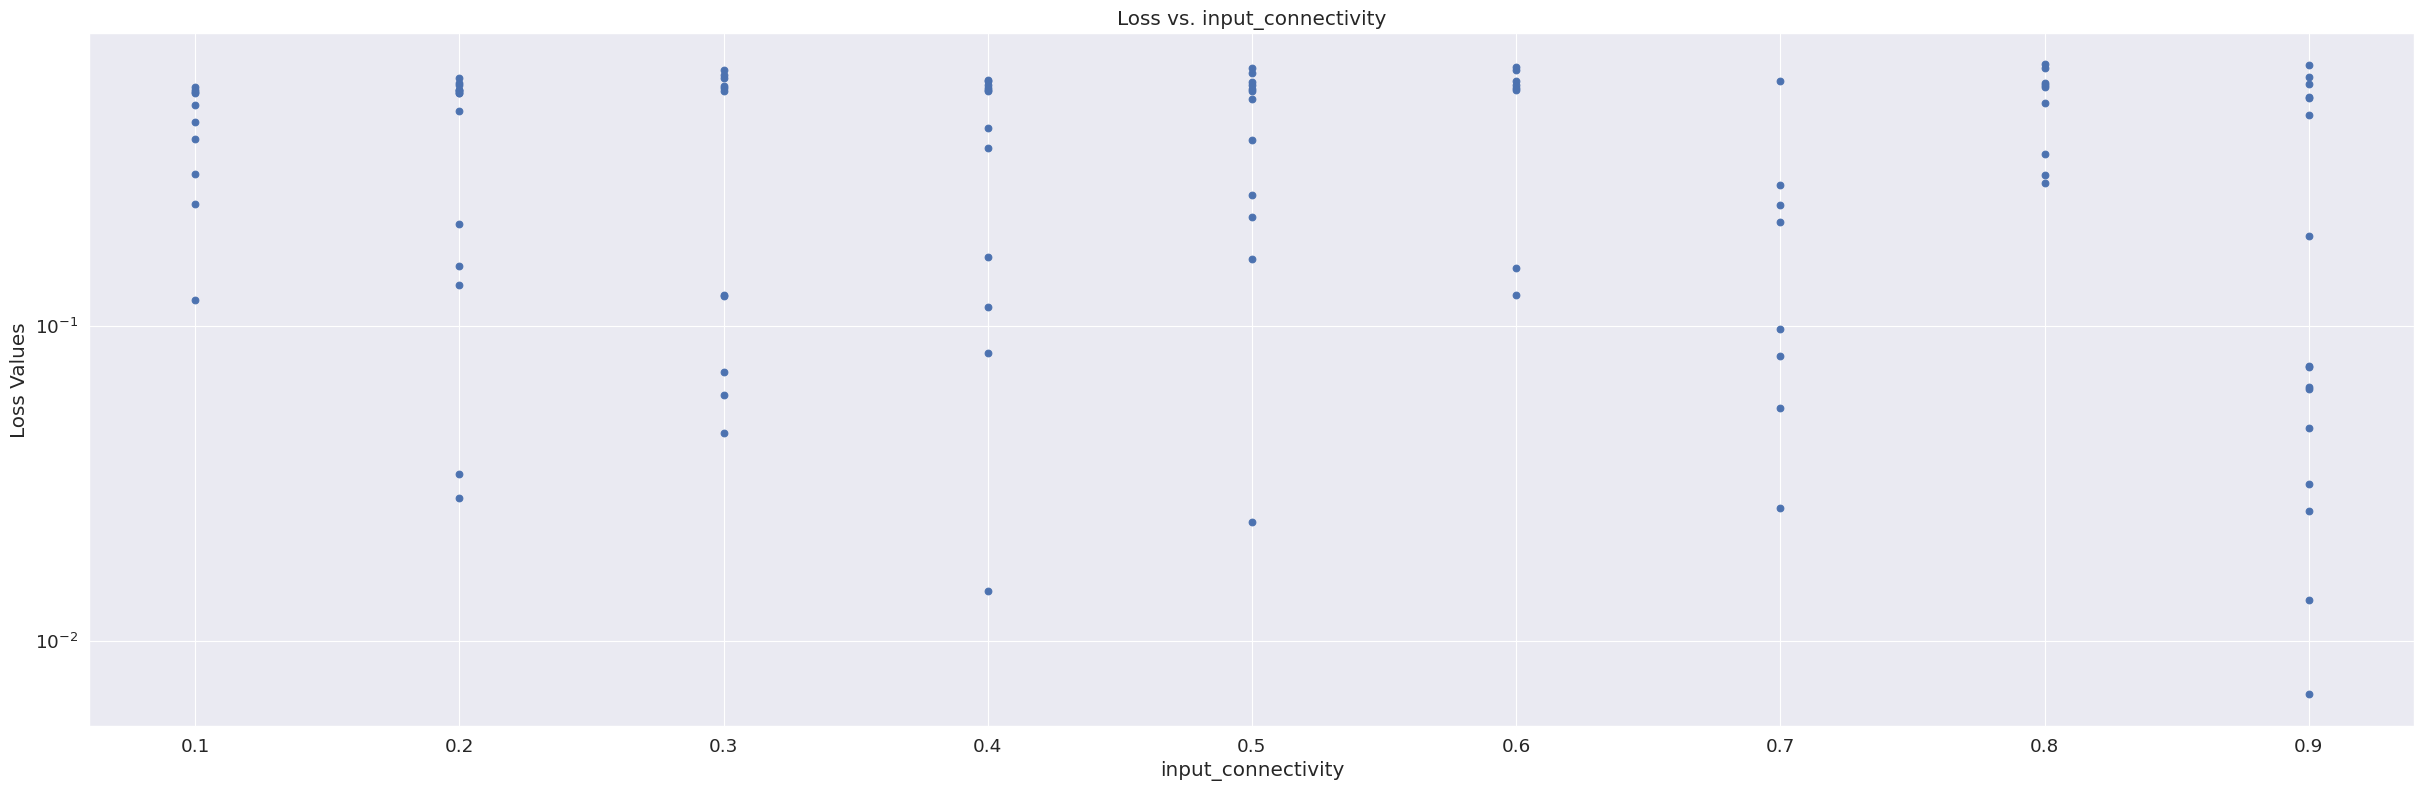

In [28]:
# prompt: how to plot the above loss matrix? the y axis is int number but loss values are tiny and bellow 1

import matplotlib.pyplot as plt

# Assuming 'loss' is your loss matrix and 'N' contains corresponding integer numbers

plt.figure(figsize=(30, 9))  # Adjust figure size as needed
plt.scatter(input_connectivity, loss)
plt.xlabel("input_connectivity")
plt.ylabel("Loss Values")
plt.title("Loss vs. input_connectivity")

# Adjust y-axis scale for better visualization of small loss values
plt.yscale('log')  # Use logarithmic scale for y-axis

plt.grid(True)
plt.show()

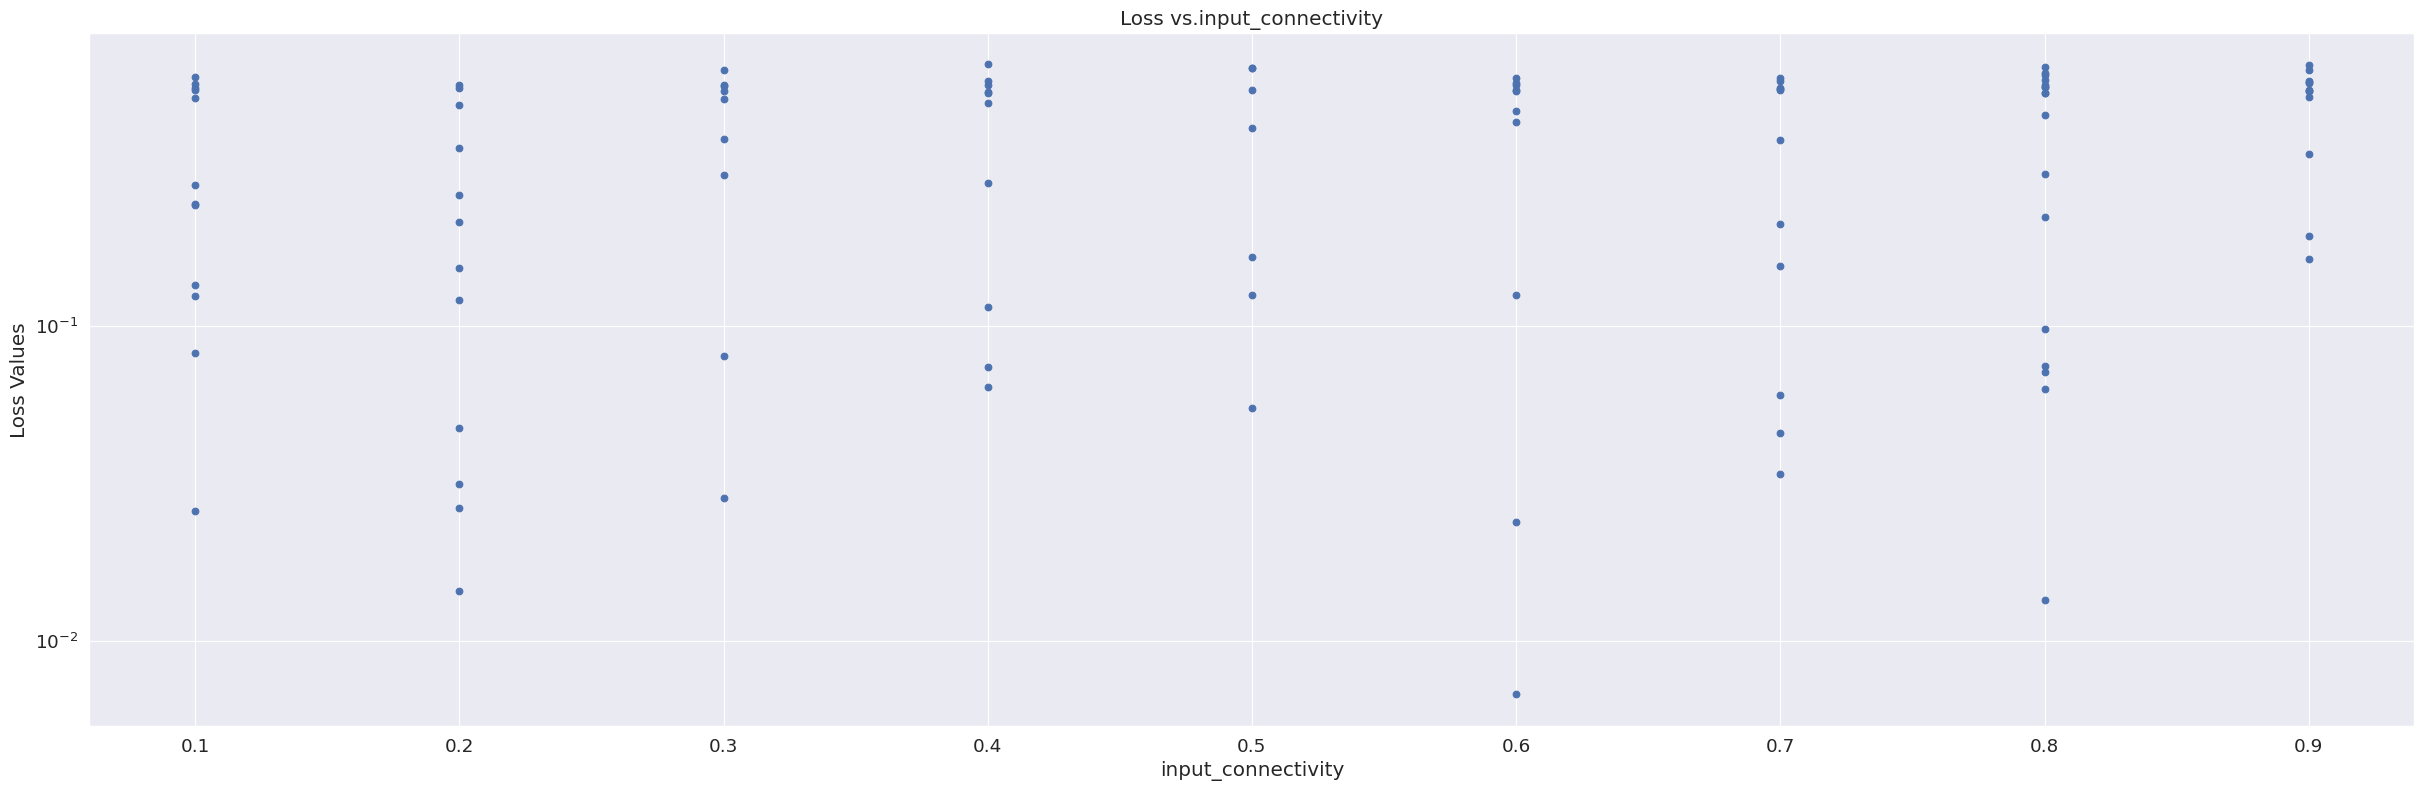

In [29]:
# prompt: how to plot the above loss matrix? the y axis is int number but loss values are tiny and bellow 1

import matplotlib.pyplot as plt

# Assuming 'loss' is your loss matrix and 'N' contains corresponding integer numbers

plt.figure(figsize=(30, 9))  # Adjust figure size as needed
plt.scatter(rc_connectivity, loss)
plt.xlabel("input_connectivity")
plt.ylabel("Loss Values")
plt.title("Loss vs.input_connectivity")

# Adjust y-axis scale for better visualization of small loss values
plt.yscale('log')  # Use logarithmic scale for y-axis

plt.grid(True)
plt.show()

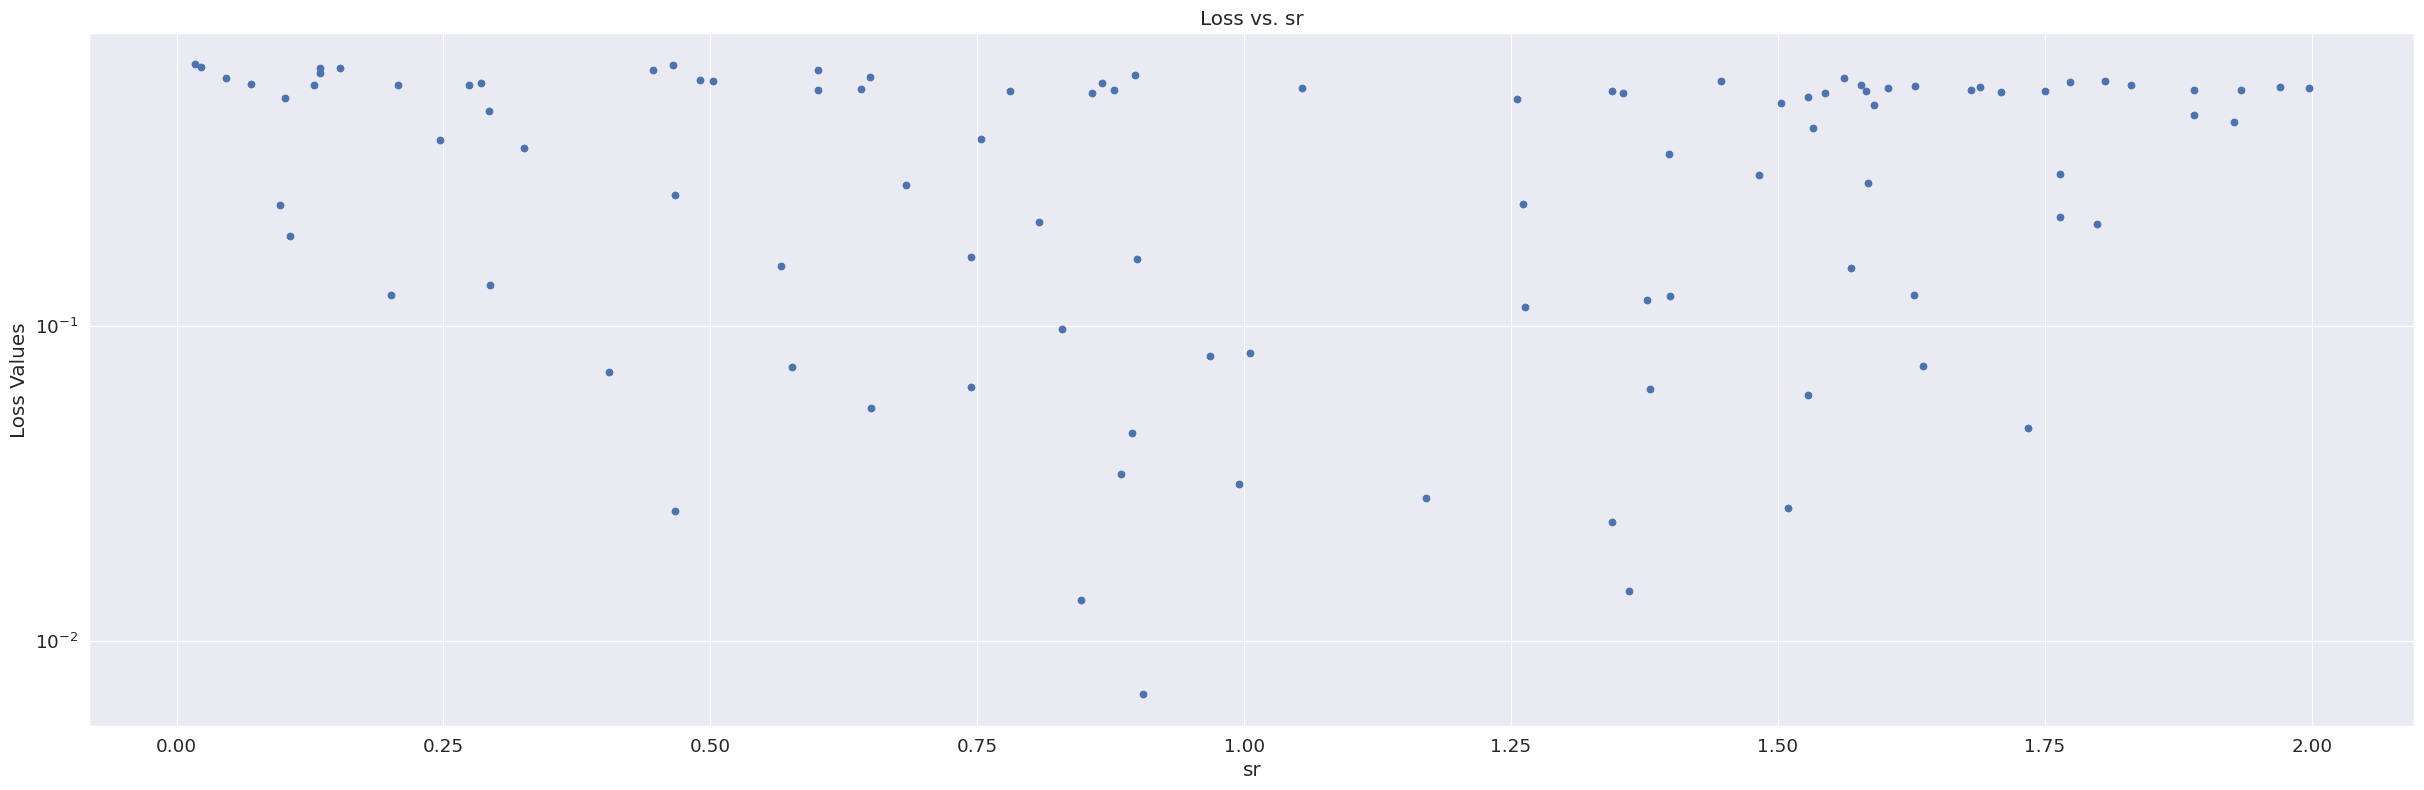

In [23]:
# prompt: how to plot the above loss matrix? the y axis is int number but loss values are tiny and bellow 1

import matplotlib.pyplot as plt

# Assuming 'loss' is your loss matrix and 'N' contains corresponding integer numbers

plt.figure(figsize=(30, 9))  # Adjust figure size as needed
plt.scatter(sr, loss)
plt.xlabel("sr")
plt.ylabel("Loss Values")
plt.title("Loss vs. sr")

# Adjust y-axis scale for better visualization of small loss values
plt.yscale('log')  # Use logarithmic scale for y-axis

plt.grid(True)
plt.show()

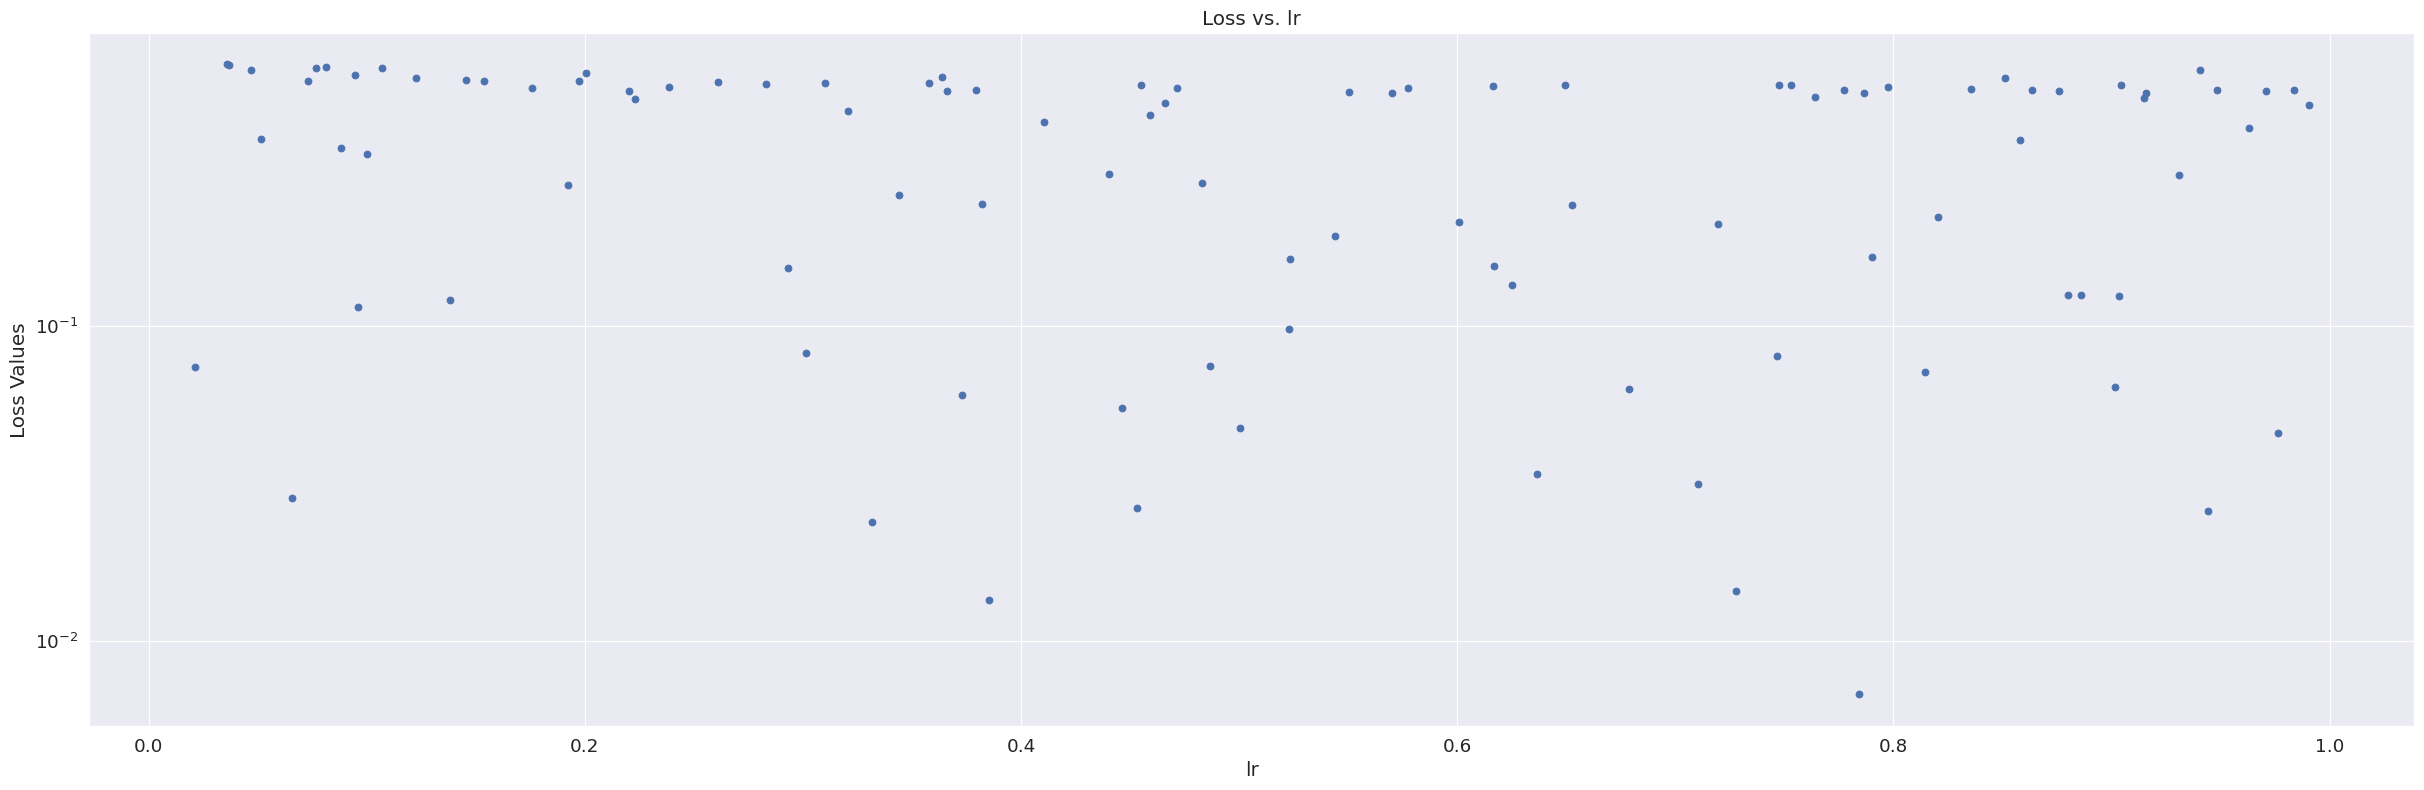

In [24]:
# prompt: how to plot the above loss matrix? the y axis is int number but loss values are tiny and bellow 1

import matplotlib.pyplot as plt

# Assuming 'loss' is your loss matrix and 'N' contains corresponding integer numbers

plt.figure(figsize=(30, 9))  # Adjust figure size as needed
plt.scatter(lr, loss)
plt.xlabel("lr")
plt.ylabel("Loss Values")
plt.title("Loss vs. lr")

# Adjust y-axis scale for better visualization of small loss values
plt.yscale('log')  # Use logarithmic scale for y-axis

plt.grid(True)
plt.show()

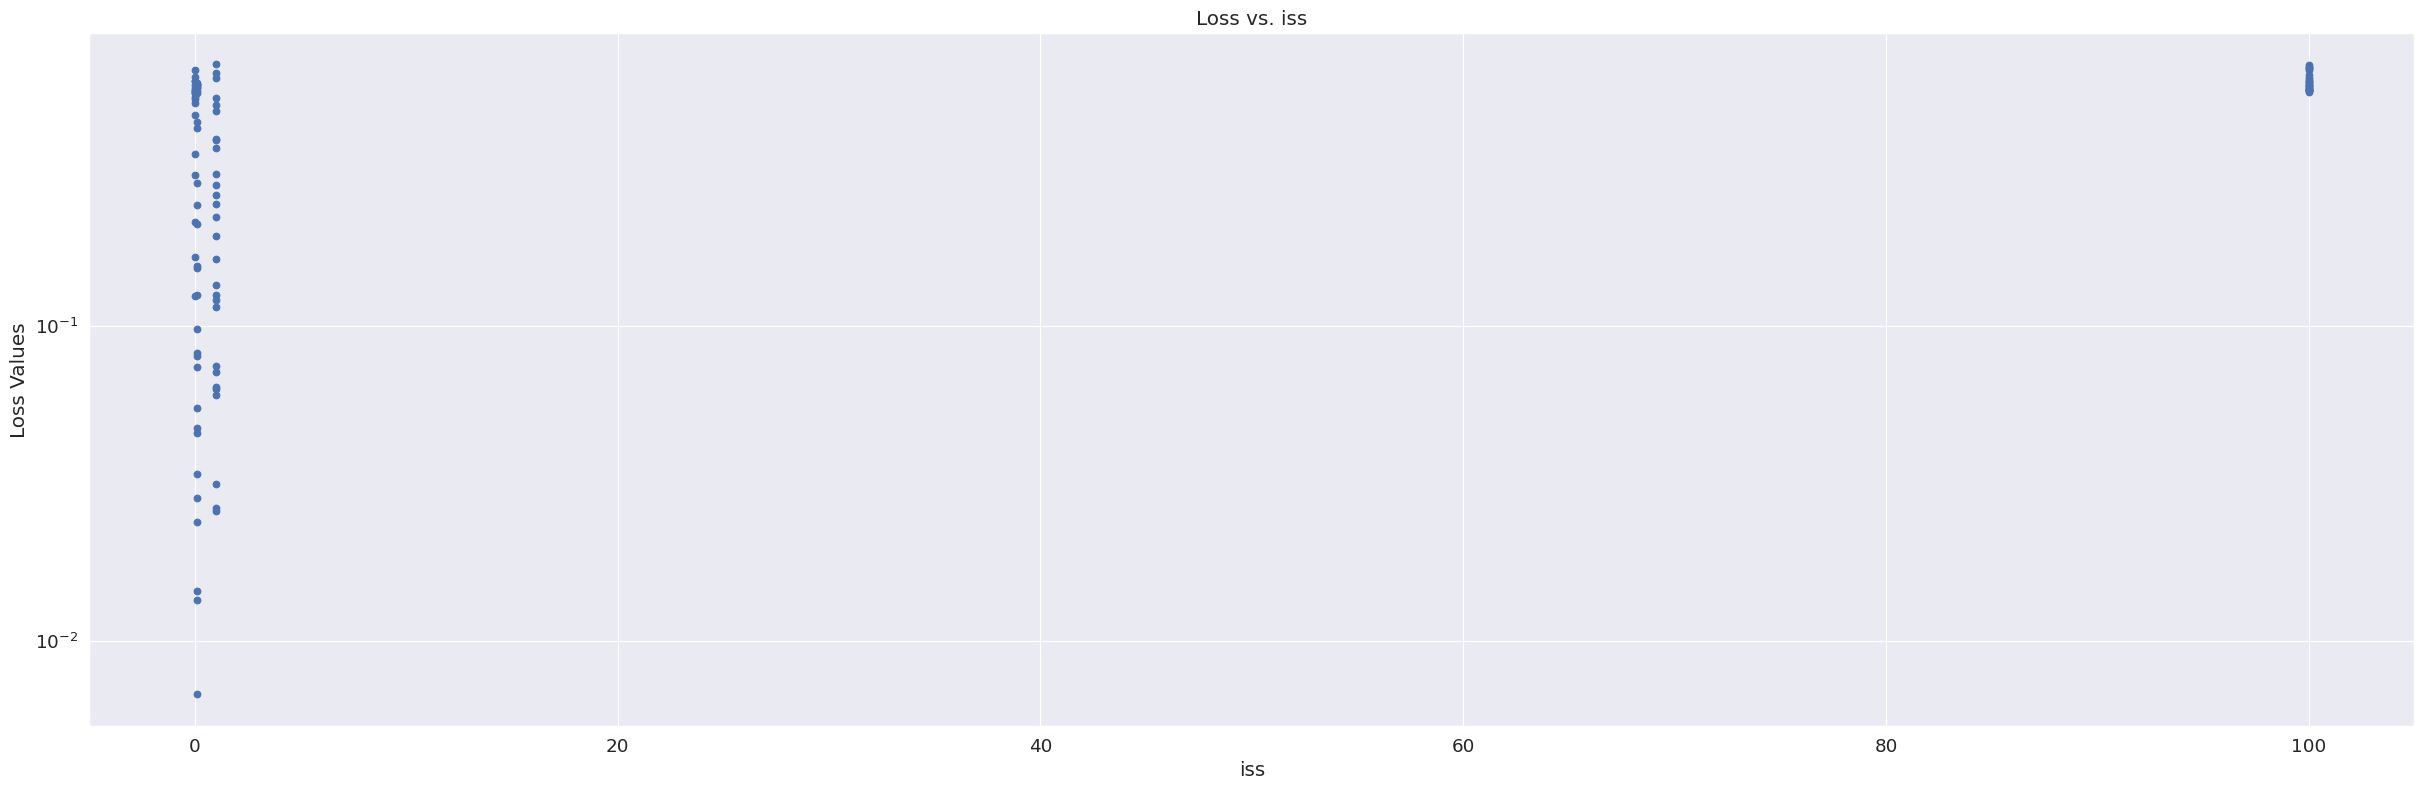

In [30]:
# prompt: how to plot the above loss matrix? the y axis is int number but loss values are tiny and bellow 1

import matplotlib.pyplot as plt

# Assuming 'loss' is your loss matrix and 'N' contains corresponding integer numbers

plt.figure(figsize=(30, 9))  # Adjust figure size as needed
plt.scatter(iss, loss)
plt.xlabel("iss")
plt.ylabel("Loss Values")
plt.title("Loss vs. iss")

# Adjust y-axis scale for better visualization of small loss values
plt.yscale('log')  # Use logarithmic scale for y-axis

plt.grid(True)
plt.show()


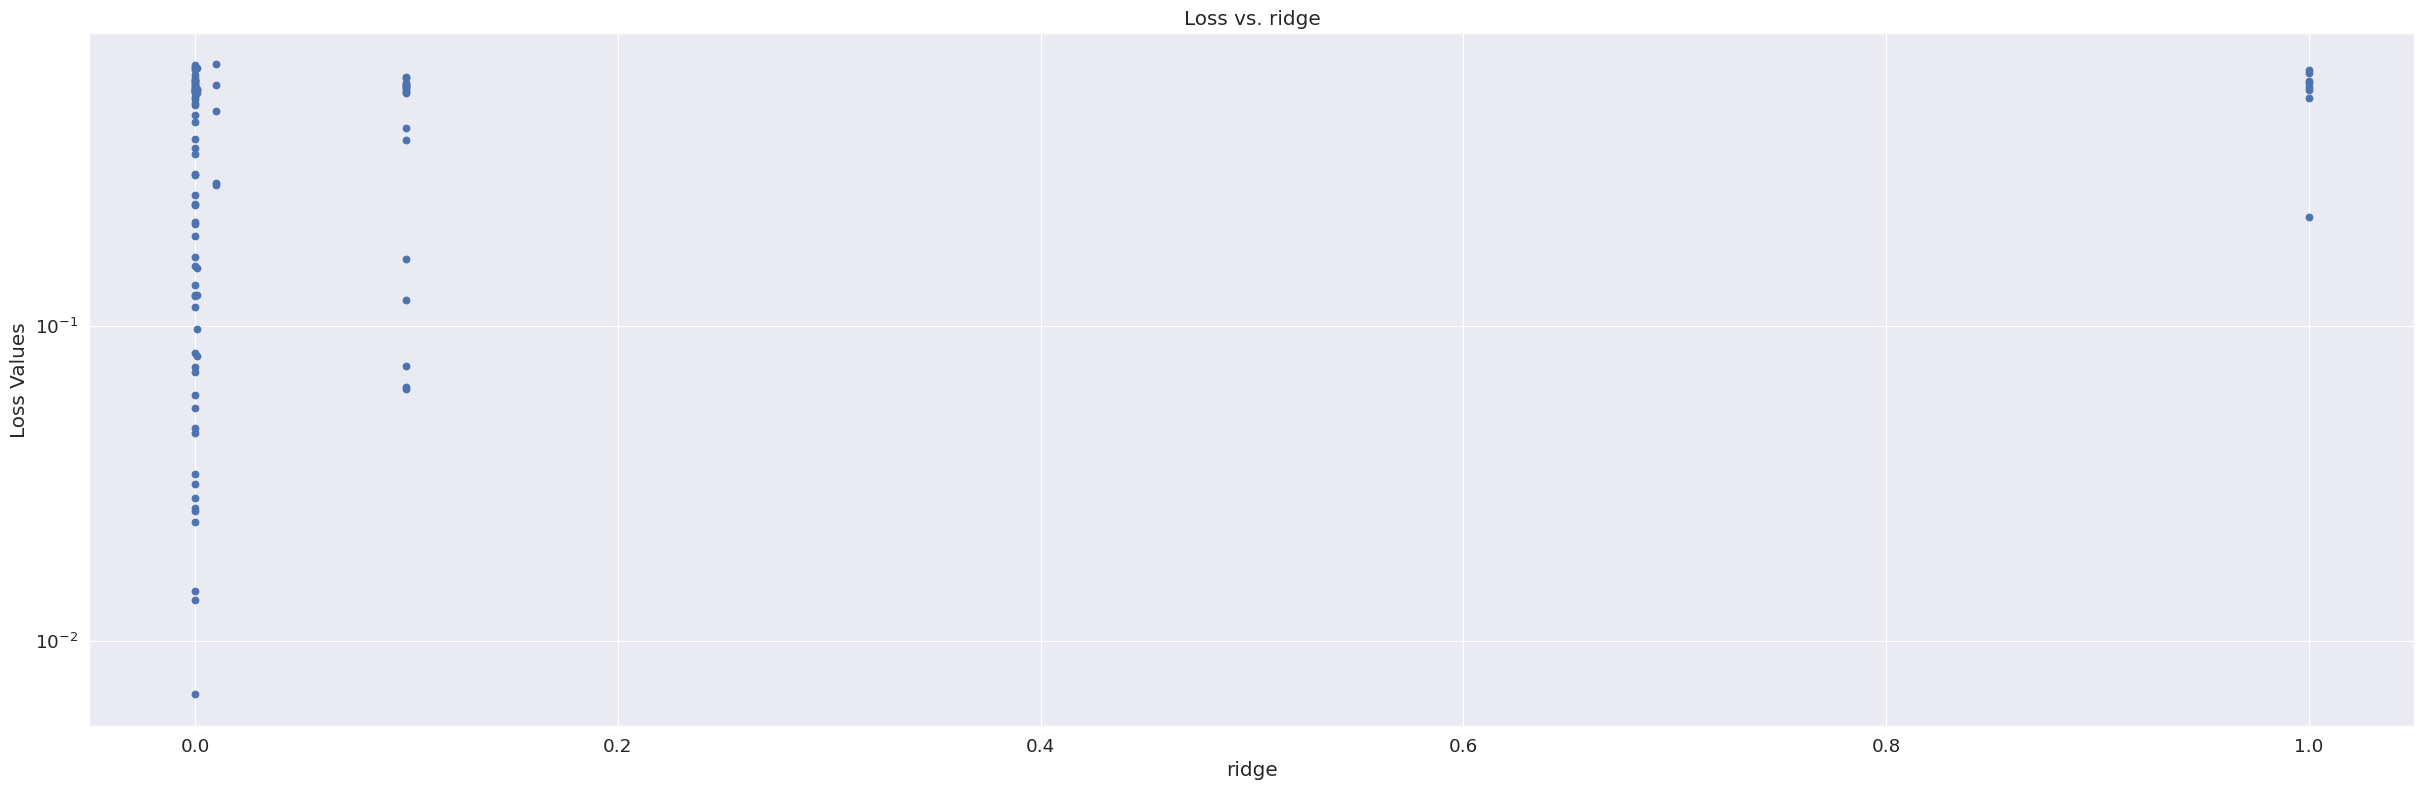

In [31]:
# prompt: how to plot the above loss matrix? the y axis is int number but loss values are tiny and bellow 1

import matplotlib.pyplot as plt

# Assuming 'loss' is your loss matrix and 'N' contains corresponding integer numbers

plt.figure(figsize=(30, 9))  # Adjust figure size as needed
plt.scatter(ridge, loss)
plt.xlabel("ridge")
plt.ylabel("Loss Values")
plt.title("Loss vs. ridge")

# Adjust y-axis scale for better visualization of small loss values
plt.yscale('log')  # Use logarithmic scale for y-axis

plt.grid(True)
plt.show()